In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [57]:
df = pd.read_csv("data.csv")   # replace with your file name

In [58]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [59]:
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [60]:
df.columns


Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [61]:
df.isnull().sum()


Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3548
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                1390
Online_Backup                  1390
Device_Protection_Plan         1390
Premium_Support                1390
Streaming_TV                   1390
Streaming_Movies               1390
Streaming_Music                1390
Unlimited_Data                 1390
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [62]:
df.drop_duplicates(inplace=True)

In [63]:
df.duplicated().sum()


np.int64(0)

In [64]:
service_cols = [
    'Online_Security','Online_Backup','Device_Protection_Plan',
    'Premium_Support','Streaming_TV','Streaming_Movies',
    'Streaming_Music','Unlimited_Data'
]

df[service_cols] = df[service_cols].fillna('No')
df['Value_Deal'] = df['Value_Deal'].fillna('No Deal')
df[['Churn_Category','Churn_Reason']] = df[['Churn_Category','Churn_Reason']].fillna('Not Churned')


In [65]:
num_cols = [
    'Total_Refunds','Total_Extra_Data_Charges',
    'Total_Long_Distance_Charges'
]

df[num_cols] = df[num_cols].fillna(0)


In [66]:
median_charge = df[df['Monthly_Charge'] > 0]['Monthly_Charge'].median()
df.loc[df['Monthly_Charge'] < 0, 'Monthly_Charge'] = median_charge


In [67]:
df.isnull().sum()


Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                        0
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                   0
Online_Backup                     0
Device_Protection_Plan            0
Premium_Support                   0
Streaming_TV                      0
Streaming_Movies                  0
Streaming_Music                   0
Unlimited_Data                    0
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [68]:
df['Multiple_Lines'] = df['Multiple_Lines'].fillna('No')#Customer doesn’t have phone service, so multiple lines is not applicable.
df['Internet_Type'] = df['Internet_Type'].fillna('No Internet')# No internet → no internet type.
#Those nulls were not missing data, 
# they represented non‑applicable services, 
# so I replaced them with business‑meaningful values.”


In [69]:
df.isnull().sum()


Customer_ID                    0
Gender                         0
Age                            0
Married                        0
State                          0
Number_of_Referrals            0
Tenure_in_Months               0
Value_Deal                     0
Phone_Service                  0
Multiple_Lines                 0
Internet_Service               0
Internet_Type                  0
Online_Security                0
Online_Backup                  0
Device_Protection_Plan         0
Premium_Support                0
Streaming_TV                   0
Streaming_Movies               0
Streaming_Music                0
Unlimited_Data                 0
Contract                       0
Paperless_Billing              0
Payment_Method                 0
Monthly_Charge                 0
Total_Charges                  0
Total_Refunds                  0
Total_Extra_Data_Charges       0
Total_Long_Distance_Charges    0
Total_Revenue                  0
Customer_Status                0
Churn_Cate

In [70]:
df.to_csv("cleaned_data.csv",index=False)

In [71]:
df['Customer_Status'].value_counts()


Customer_Status
Stayed     4275
Churned    1732
Joined      411
Name: count, dtype: int64

In [72]:
df.groupby('Gender')['Customer_Status'].value_counts()


Gender  Customer_Status
Female  Stayed             2668
        Churned            1111
        Joined              269
Male    Stayed             1607
        Churned             621
        Joined              142
Name: count, dtype: int64

In [73]:
pd.crosstab(df['Internet_Service'], df['Customer_Status'])


Customer_Status,Churned,Joined,Stayed
Internet_Service,,,
No,109,167,1114
Yes,1623,244,3161


In [74]:
df.groupby('Customer_Status')['Tenure_in_Months'].mean()

Customer_Status
Churned    17.515589
Joined     16.586375
Stayed     17.345497
Name: Tenure_in_Months, dtype: float64

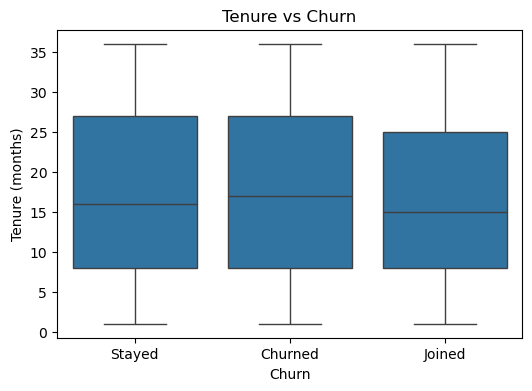

In [75]:
#Tenure vs Churn 
plt.figure(figsize=(6,4))
sns.boxplot(x='Customer_Status', y='Tenure_in_Months', data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()


In [76]:
#Monthly charge summary
df.groupby('Customer_Status')['Monthly_Charge'].mean()


Customer_Status
Churned    74.279965
Joined     43.774453
Stayed     63.158526
Name: Monthly_Charge, dtype: float64

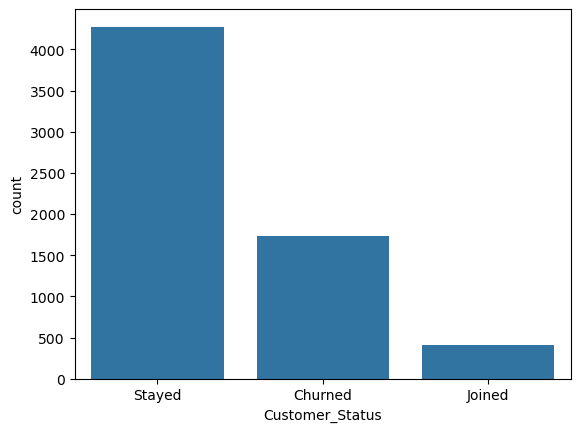

In [77]:
sns.countplot(x='Customer_Status', data=df)
plt.show()


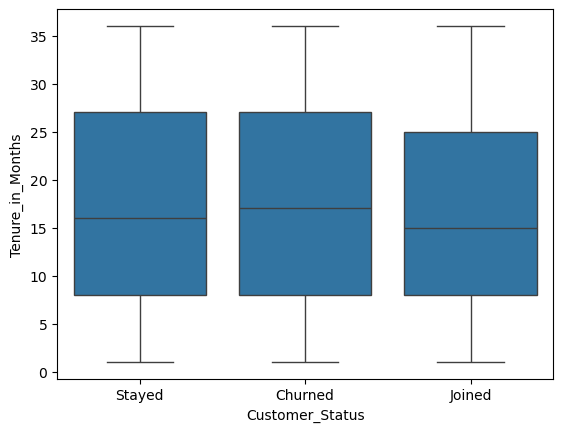

In [78]:
sns.boxplot(x='Customer_Status', y='Tenure_in_Months', data=df)
plt.show()


In [79]:
yes_no_cols = [
    'Phone_Service','Online_Security','Online_Backup',
    'Device_Protection_Plan','Premium_Support',
    'Streaming_TV','Streaming_Movies',
    'Streaming_Music','Unlimited_Data'
]
for col in yes_no_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})


In [80]:
df[yes_no_cols].dtypes

Phone_Service             int64
Online_Security           int64
Online_Backup             int64
Device_Protection_Plan    int64
Premium_Support           int64
Streaming_TV              int64
Streaming_Movies          int64
Streaming_Music           int64
Unlimited_Data            int64
dtype: object

In [81]:
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})


In [82]:
df['Customer_Status'] = df['Customer_Status'].map({
    'Stayed': 0,
    'Churned': 1,
    'Joined': 0
})


In [83]:
df['Multiple_Lines'] = df['Multiple_Lines'].map({'Yes': 1, 'No': 0})


In [84]:
#df.drop(columns=['Customer_ID'], inplace=True)
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [85]:
df['Internet_Service'] = df['Internet_Service'].map({'Yes': 1, 'No': 0})


In [86]:
binary_cols = [
    'Phone_Service','Online_Security','Online_Backup',
    'Device_Protection_Plan','Premium_Support',
    'Streaming_TV','Streaming_Movies',
    'Streaming_Music','Unlimited_Data'
]

df[binary_cols].isnull().sum()


Phone_Service             0
Online_Security           0
Online_Backup             0
Device_Protection_Plan    0
Premium_Support           0
Streaming_TV              0
Streaming_Movies          0
Streaming_Music           0
Unlimited_Data            0
dtype: int64

In [87]:
df[binary_cols] = df[binary_cols].fillna(0)
df[binary_cols] = df[binary_cols].astype(int)
df[binary_cols].dtypes

Phone_Service             int64
Online_Security           int64
Online_Backup             int64
Device_Protection_Plan    int64
Premium_Support           int64
Streaming_TV              int64
Streaming_Movies          int64
Streaming_Music           int64
Unlimited_Data            int64
dtype: object

In [88]:
corr = df.corr(numeric_only=True)
corr

,Gender,Age,Number_of_Referrals,Tenure_in_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection_Plan,...,Streaming_Movies,Streaming_Music,Unlimited_Data,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status
Gender,1.000000,0.041547,-0.015721,0.040560,-0.027623,-0.016475,0.019823,-0.009703,0.007233,0.011234,...,-0.005385,-0.015745,0.014870,-0.011812,-0.008154,-0.010585,-0.002130,-0.009645,-0.009293,-0.013516
Age,0.041547,1.000000,-0.009325,0.150851,0.014347,0.106107,0.111750,-0.036920,0.036207,0.029360,...,0.073066,-0.153640,0.073978,0.140707,0.058049,0.017724,0.029559,0.005049,0.047629,0.111899
Number_of_Referrals,-0.015721,-0.009325,1.000000,-0.010544,-0.012978,-0.038098,-0.002069,0.006622,0.002859,-0.011707,...,-0.006915,-0.007609,0.003144,-0.006679,-0.000224,0.014115,-0.003736,0.011571,0.003174,-0.004637
Tenure_in_Months,0.040560,0.150851,-0.010544,1.000000,-0.004820,0.008550,-0.004025,-0.007423,-0.005299,-0.011282,...,0.009883,-0.027891,-0.017639,-0.000015,-0.000433,0.010795,0.025323,0.004512,0.001181,0.009934
Phone_Service,-0.027623,0.014347,-0.012978,-0.004820,1.000000,0.280414,-0.172243,-0.092514,-0.057664,-0.071731,...,-0.035553,-0.042751,-0.124812,0.245868,0.112111,0.005203,-0.031127,0.289365,0.173993,0.005762
Multiple_Lines,-0.016475,0.106107,-0.038098,0.008550,0.280414,1.000000,0.209642,0.101171,0.200038,0.197804,...,0.255612,0.187141,0.155095,0.485722,0.468083,0.039816,0.070117,0.325047,0.466976,0.035941
Internet_Service,0.019823,0.111750,-0.002069,-0.004025,-0.172243,0.209642,1.000000,0.331304,0.380775,0.381169,...,0.421100,0.387899,0.758238,0.756697,0.374563,0.018832,0.142899,-0.016189,0.292757,0.226771
Online_Security,-0.009703,-0.036920,0.006622,-0.007423,-0.092514,0.101171,0.331304,1.000000,0.287595,0.275251,...,0.187074,0.194618,0.265786,0.293918,0.415365,0.009485,0.053456,0.202824,0.389061,-0.176067
Online_Backup,0.007233,0.036207,0.002859,-0.005299,-0.057664,0.200038,0.380775,0.287595,1.000000,0.302548,...,0.277064,0.245648,0.282949,0.435815,0.509262,0.023177,0.098253,0.240356,0.474802,-0.080439
Device_Protection_Plan,0.011234,0.029360,-0.011707,-0.011282,-0.071731,0.197804,0.381169,0.275251,0.302548,1.000000,...,0.395802,0.344362,0.294043,0.476804,0.520616,0.033809,0.078987,0.206555,0.473594,-0.069932


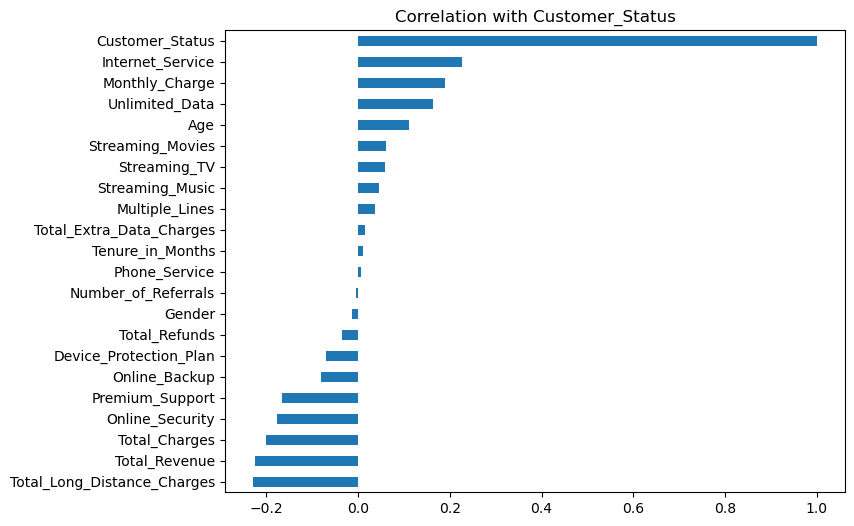

In [89]:
corr_churn = df.corr(numeric_only=True)['Customer_Status'].sort_values()

import matplotlib.pyplot as plt

corr_churn.plot(kind='barh', figsize=(8,6))
plt.title("Correlation with Customer_Status")
plt.show()


In [90]:
corr_churn = df.corr(numeric_only=True)['Customer_Status']

important_features = corr_churn[abs(corr_churn) > 0.02].index
important_features


Index(['Age', 'Multiple_Lines', 'Internet_Service', 'Online_Security',
       'Online_Backup', 'Device_Protection_Plan', 'Premium_Support',
       'Streaming_TV', 'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data',
       'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Long_Distance_Charges', 'Total_Revenue', 'Customer_Status'],
      dtype='object')

In [91]:
important_features = important_features.drop(
    ['Customer_Status'], errors='ignore'
)


In [92]:
final_df = df[important_features]
final_df.head()


,Age,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection_Plan,Premium_Support,Streaming_TV,Streaming_Movies,Streaming_Music,Unlimited_Data,Monthly_Charge,Total_Charges,Total_Refunds,Total_Long_Distance_Charges,Total_Revenue
0,35,0,1,0,1,0,1,1,0,0,1,65.6,593.30,0.00,381.51,974.81
1,45,1,1,0,0,0,0,0,1,1,0,70.4,542.40,38.33,96.21,610.28
2,51,0,1,0,0,1,0,0,0,0,1,73.9,280.85,0.00,134.60,415.45
3,79,0,1,0,1,1,0,1,1,0,1,98.0,1237.85,0.00,361.66,1599.51
4,80,0,1,0,0,0,1,1,0,0,1,83.9,267.40,0.00,22.14,289.54


In [93]:
final_df.to_csv("churn_cleaned_final.csv", index=False)

In [94]:
X = df[important_features]
y = df['Customer_Status']

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [97]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [98]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Predict using logistic regression
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.8037383177570093

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.91      0.87       965
           1       0.64      0.47      0.55       319

    accuracy                           0.80      1284
   macro avg       0.74      0.69      0.71      1284
weighted avg       0.79      0.80      0.79      1284


Confusion Matrix:
 [[881  84]
 [168 151]]


In [100]:
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nDecision Tree Classification Report:\n",
      classification_report(y_test, y_pred_dt))
print("\nDecision Tree Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 0.794392523364486

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.95      0.87       965
           1       0.67      0.34      0.45       319

    accuracy                           0.79      1284
   macro avg       0.74      0.64      0.66      1284
weighted avg       0.78      0.79      0.77      1284


Decision Tree Confusion Matrix:
 [[912  53]
 [211 108]]


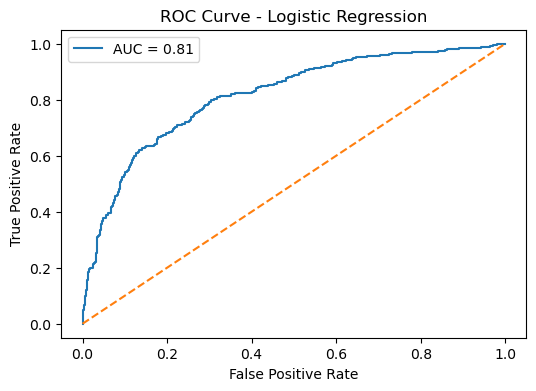

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
y_prob = model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()
